In [1]:
import re
import pandas as pd
import numpy as np
from urllib.parse import urlparse
import tldextract

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


# Load datasets

In [3]:
# Change 'data.csv' to your actual file name
df = pd.read_csv(r"C:\Users\Rohit94\Documents\project_2023\Url nlp\WebAPP\phishing_data.csv")   # columns: 'url', 'label'

In [4]:
df

,url,class
0,http://www.conceptdraw.com/How-To-Guide/Local-...,legitimate
1,https://www.edrawsoft.com/Local-Area-Network.php,legitimate
2,http://www.webopedia.com/TERM/L/local_area_net...,legitimate
3,https://www.acsac.org/secshelf/book001/16.pdf,legitimate
4,http://www.diffen.com/difference/LAN_vs_WAN,legitimate
...,...,...
73570,http://www.grupolyl.com/slap/GD/,phishing
73571,http://bcgroup-sa.com/nilalalaa/GD/index.php,phishing
73572,http://mainepta.org/eme/gm/excel/excel/excel.p...,phishing
73573,http://support.escola-olivera.org/GOOGLENEWW/G...,phishing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73575 entries, 0 to 73574
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     73575 non-null  object
 1   class   73575 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [6]:
df.describe()

,url,class
count,73575,73575
unique,54763,2
top,apple-iforget.com,phishing
freq,15,37175


In [7]:
df.isnull().sum()

url      0
class    0
dtype: int64

In [9]:
# Count of each class
print(df['class'].value_counts())

phishing      37175
legitimate    36400
Name: class, dtype: int64


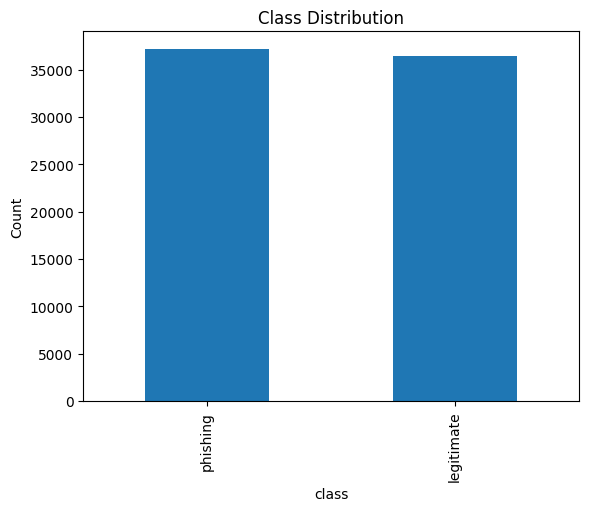

In [11]:
import matplotlib.pyplot as plt

df['class'].value_counts().plot(kind='bar')
plt.xlabel('class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()


# Feature extraction from a single URL

In [12]:
def extract_features(url: str):
    # Ensure it has a scheme
    if not re.match(r'^https?://', url):
        url = 'http://' + url

    parsed = urlparse(url)
    ext = tldextract.extract(url)

    hostname = parsed.netloc
    path = parsed.path
    query = parsed.query

    url_length = len(url)
    hostname_length = len(hostname)
    path_length = len(path)

    num_dots = hostname.count('.')
    num_hyphen = hostname.count('-')
    num_slash = url.count('/')
    num_digits = sum(c.isdigit() for c in url)
    num_params = query.count('=') if query else 0

    # IP address in hostname?
    has_ip = 1 if re.fullmatch(r'(?:\d{1,3}\.){3}\d{1,3}', hostname.split(':')[0]) else 0

    has_at = 1 if '@' in url else 0
    uses_https = 1 if parsed.scheme == 'https' else 0

    return [
        url_length,
        hostname_length,
        path_length,
        num_dots,
        num_hyphen,
        num_slash,
        num_digits,
        num_params,
        has_ip,
        has_at,
        uses_https,
    ]

feature_names = [
    "url_length", "hostname_length", "path_length",
    "num_dots", "num_hyphen", "num_slash",
    "num_digits", "num_params", "has_ip",
    "has_at", "uses_https"
]


In [14]:

# Encode labels: legitimate = 0, phishing = 1 (for example)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['class'])

In [15]:
df

,url,class,label_encoded
0,http://www.conceptdraw.com/How-To-Guide/Local-...,legitimate,0
1,https://www.edrawsoft.com/Local-Area-Network.php,legitimate,0
2,http://www.webopedia.com/TERM/L/local_area_net...,legitimate,0
3,https://www.acsac.org/secshelf/book001/16.pdf,legitimate,0
4,http://www.diffen.com/difference/LAN_vs_WAN,legitimate,0
...,...,...,...
73570,http://www.grupolyl.com/slap/GD/,phishing,1
73571,http://bcgroup-sa.com/nilalalaa/GD/index.php,phishing,1
73572,http://mainepta.org/eme/gm/excel/excel/excel.p...,phishing,1
73573,http://support.escola-olivera.org/GOOGLENEWW/G...,phishing,1


In [16]:
feature_names

['url_length',
 'hostname_length',
 'path_length',
 'num_dots',
 'num_hyphen',
 'num_slash',
 'num_digits',
 'num_params',
 'has_ip',
 'has_at',
 'uses_https']

In [17]:
# Build feature matrix
X = np.array([extract_features(u) for u in df['url']])
y = df['label_encoded'].values

In [18]:
X

array([[ 58,  19,  32, ...,   0,   0,   0],
       [ 48,  17,  23, ...,   0,   0,   1],
       [ 59,  17,  35, ...,   0,   0,   0],
       ...,
       [286,  12,  29, ...,   0,   1,   0],
       [ 95,  26,  62, ...,   0,   0,   0],
       [ 56,  26,  23, ...,   0,   0,   0]])

In [19]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
X_train

array([[41, 15, 19, ...,  0,  0,  0],
       [98, 21, 70, ...,  0,  0,  0],
       [57, 13, 37, ...,  0,  0,  0],
       ...,
       [70, 17, 28, ...,  0,  0,  0],
       [56, 21, 28, ...,  0,  0,  0],
       [34, 15, 12, ...,  0,  0,  0]])

In [22]:
X_train.shape

(58860, 11)

In [23]:
y_train

array([0, 0, 0, ..., 1, 1, 1])

# Train and compare multiple algorithms

# Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


=== Logistic Regression ===
Accuracy: 0.8240570846075433

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.84      0.80      0.82      7280
    phishing       0.81      0.85      0.83      7435

    accuracy                           0.82     14715
   macro avg       0.82      0.82      0.82     14715
weighted avg       0.82      0.82      0.82     14715


Confusion Matrix:
 [[5832 1448]
 [1141 6294]]


# Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


=== Decision Tree ===
Accuracy: 0.8850152905198777

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.89      0.88      0.88      7280
    phishing       0.88      0.89      0.89      7435

    accuracy                           0.89     14715
   macro avg       0.89      0.88      0.88     14715
weighted avg       0.89      0.89      0.89     14715


Confusion Matrix:
 [[6395  885]
 [ 807 6628]]


# Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


=== Random Forest ===
Accuracy: 0.9029561671763506

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.91      0.89      0.90      7280
    phishing       0.89      0.92      0.91      7435

    accuracy                           0.90     14715
   macro avg       0.90      0.90      0.90     14715
weighted avg       0.90      0.90      0.90     14715


Confusion Matrix:
 [[6480  800]
 [ 628 6807]]


# K-Nearest Neighbors

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("=== K-Nearest Neighbors ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


C:\Users\Rohit94\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


=== K-Nearest Neighbors ===
Accuracy: 0.855249745158002

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.86      0.84      0.85      7280
    phishing       0.85      0.87      0.86      7435

    accuracy                           0.86     14715
   macro avg       0.86      0.86      0.86     14715
weighted avg       0.86      0.86      0.86     14715


Confusion Matrix:
 [[6142 1138]
 [ 992 6443]]


# AdaBoost

In [31]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=200, random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))


=== AdaBoost ===
Accuracy: 0.8643560992184846

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.87      0.86      0.86      7280
    phishing       0.86      0.87      0.87      7435

    accuracy                           0.86     14715
   macro avg       0.86      0.86      0.86     14715
weighted avg       0.86      0.86      0.86     14715


Confusion Matrix:
 [[6225 1055]
 [ 941 6494]]


# Gradient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


=== Gradient Boosting ===
Accuracy: 0.8673462453278967

Classification Report:
               precision    recall  f1-score   support

  legitimate       0.87      0.86      0.87      7280
    phishing       0.86      0.87      0.87      7435

    accuracy                           0.87     14715
   macro avg       0.87      0.87      0.87     14715
weighted avg       0.87      0.87      0.87     14715


Confusion Matrix:
 [[6258 1022]
 [ 930 6505]]


In [33]:
import joblib

# Save
joblib.dump(rf_model, "rf_phishing_model.pkl")
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']

In [34]:
import numpy as np
import joblib
import re
from urllib.parse import urlparse
import tldextract

# same extract_features function you used before
def extract_features(url: str):
    if not re.match(r'^https?://', url):
        url = 'http://' + url

    parsed = urlparse(url)
    ext = tldextract.extract(url)

    hostname = parsed.netloc
    path = parsed.path
    query = parsed.query

    url_length = len(url)
    hostname_length = len(hostname)
    path_length = len(path)

    num_dots = hostname.count('.')
    num_hyphen = hostname.count('-')
    num_slash = url.count('/')
    num_digits = sum(c.isdigit() for c in url)
    num_params = query.count('=') if query else 0

    has_ip = 1 if re.fullmatch(r'(?:\d{1,3}\.){3}\d{1,3}', hostname.split(':')[0]) else 0
    has_at = 1 if '@' in url else 0
    uses_https = 1 if parsed.scheme == 'https' else 0

    return [
        url_length,
        hostname_length,
        path_length,
        num_dots,
        num_hyphen,
        num_slash,
        num_digits,
        num_params,
        has_ip,
        has_at,
        uses_https,
    ]

# Load model and encoder
rf_loaded = joblib.load("rf_phishing_model.pkl")
le_loaded = joblib.load("label_encoder.pkl")

def predict_url(url: str):
    feats = np.array(extract_features(url)).reshape(1, -1)
    pred = rf_loaded.predict(feats)[0]
    label = le_loaded.inverse_transform([pred])[0]
    return label  # "phishing" or "legitimate"


In [37]:
predict_url("http://www.dictionary.com/browse/lan")

'legitimate'